# TDA Persistent Homology on Real Data — v2 (gate-validated configuration)

**Provenance:** configuration validated in `tda_gate_validation_v3`
(all hard gates passed at d=5, n=1500: sine, torus both loops, Lorenz
x/y, noise and AR(1) nulls clean, seed-stable).

**What the instrument is validated to measure [important]:** persistent
rotational/oscillatory deterministic structure in delay reconstructions.
Gate G (true-state-space Lorenz) FAILED (top1/floor=1.68), so this
statistic is NOT validated as a faithful measure of attractor homology —
the delay embedding plausibly amplifies orbital-oscillation loops beyond
the attractor's intrinsic holes. All conclusions must be phrased as
"H1 persistence of delay reconstructions", never "attractor topology".

**Changes vs v1 of this notebook (all gate-mandated):**
1. robust_tau (smoothed MI, windowed minimum, ACF fallback) — v1's
   first-strict-minimum picked spurious dips (tau=5 on a period-100 sine).
2. d = 5 (Takens bound for dim~2 objects; d=3 failed gates B and C).
3. n_points = 1500.
4. Per-channel shuffle-surrogate floor (M=10, p95): each channel is
   compared against its OWN permutation null, so marginal shape and
   density are controlled per channel.
5. Reported statistics per channel: top1, top1/own_floor, top1/top2,
   top1/total, n_features — not max_pers alone.

**Pre-registered interpretation forks (fixed before running):**
- Structure signature = top1/own_floor >= 3 (the gate bar) with
  low-to-moderate n_features; noise signature = top1/own_floor near 1.
- FORK 1: Weather channels predominantly structured AND ETTh channels
  predominantly noise-like -> supports (correlation only) the hypothesis
  that Panda transfers where delay-reconstructed deterministic loop
  structure exists. Next causal step: synthetic interpolation.
- FORK 2: no separation between Weather and ETTh -> the structure
  hypothesis is not supported on this statistic; deprioritise the
  geometry/structure branch, weight shifts to heterogeneity and
  signal-family candidates.
- FORK 3: Weather is internally split (some channels structured, some
  not) -> per-channel result; cross-reference with the heterogeneity
  work (does Panda's per-channel accuracy on Weather track the
  per-channel structure statistic?). This would be the most
  informative outcome, linking branches B1 and B2.
- Either way: correlational. Confounds that could track both the
  statistic and Panda's advantage: sampling rate relative to dominant
  period, noise level, stationarity, quantisation of sensor readings.

**Statistical caution:** channels within a dataset share physical
drivers and are NOT independent samples; report medians and IQRs and
per-channel values. No significance test across datasets is attempted
at this stage.

**Runtime:** ~(21+7+7+3) channels x 11 ripser calls at 1500 points
= ~420 calls. Expect 1-3 h CPU. Results are saved incrementally per
dataset so a crash loses at most one dataset.

In [1]:
import numpy as np
import pandas as pd
import warnings, time, os
warnings.filterwarnings('ignore')
np.random.seed(42)

from ripser import ripser

D_EMBED   = 5
N_POINTS  = 1500
MAX_TAU   = 80
M_SUR     = 10
Q_FLOOR   = 95
EPS       = 1e-12
N_POINTS_TIMESERIES = 3000
STRUCT_BAR = 3.0   # gate-validated structure threshold (top1/own_floor)

## Load real data — replace paths with your local files

In [2]:
WEATHER_PATH = "ts_data/weather.csv"
ETTH1_PATH   = "ts_data/ETTh1.csv"
ETTH2_PATH   = "ts_data/ETTh2.csv"

date_cols = ['date']

def load_csv(path):
    df = pd.read_csv(path)
    cols = [c for c in df.columns if c not in date_cols]
    return df[cols].values[:N_POINTS_TIMESERIES].astype(float), cols

weather_data, weather_cols = load_csv(WEATHER_PATH)
etth1_data,   etth1_cols   = load_csv(ETTH1_PATH)
etth2_data,   etth2_cols   = load_csv(ETTH2_PATH)
print(f"Weather {weather_data.shape}, ETTh1 {etth1_data.shape}, ETTh2 {etth2_data.shape}")

Weather (3000, 21), ETTh1 (3000, 7), ETTh2 (3000, 7)


## Pipeline (identical to gate notebook v3 — do not edit independently)

In [3]:
def mi_curve(x, max_lag=100, n_bins=16):
    mis = []
    for lag in range(1, max_lag + 1):
        x1, x2 = x[:-lag], x[lag:]
        hist2d, _, _ = np.histogram2d(x1, x2, bins=n_bins)
        hist2d = hist2d / hist2d.sum()
        px = hist2d.sum(axis=1, keepdims=True)
        py = hist2d.sum(axis=0, keepdims=True)
        outer = px @ py
        mask = (hist2d > 0) & (outer > 0)
        mis.append(np.sum(hist2d[mask] * np.log(hist2d[mask] / outer[mask])))
    return np.array(mis)

def robust_tau(x, max_lag=100, n_bins=16, smooth_w=5, min_win=2):
    mis = mi_curve(x, max_lag=max_lag, n_bins=n_bins)
    kernel = np.ones(smooth_w) / smooth_w
    pad = smooth_w // 2
    padded = np.concatenate([np.full(pad, mis[0]), mis, np.full(pad, mis[-1])])
    smooth = np.convolve(padded, kernel, mode='valid')
    for i in range(min_win, len(smooth) - min_win):
        window = smooth[i - min_win: i + min_win + 1]
        if smooth[i] == window.min() and (window > smooth[i]).sum() == len(window) - 1:
            return i + 1
    xc = x - x.mean()
    acf_denom = np.dot(xc, xc)
    for lag in range(1, max_lag + 1):
        if np.dot(xc[:-lag], xc[lag:]) / acf_denom <= 0:
            return lag
    return max_lag // 4

def delay_embed(x, d, tau):
    N = len(x) - (d - 1) * tau
    if N <= 0:
        raise ValueError(f"Signal too short for d={d}, tau={tau}: len={len(x)}")
    return np.stack([x[i*tau : i*tau + N] for i in range(d)], axis=1)

def subsample_cloud(cloud, n=800, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(cloud), size=min(n, len(cloud)), replace=False)
    return cloud[idx]

def compute_h1_persistence(cloud):
    result = ripser(cloud, maxdim=1)
    h1 = result['dgms'][1]
    return h1[np.isfinite(h1[:, 1])] if len(h1) > 0 else h1

def simulate_lorenz(n=5000, dt=0.01, sigma=10, rho=28, beta=8/3):
    x, y, z = 0.1, 0.0, 0.0
    xs, ys, zs = [x], [y], [z]
    for _ in range(n - 1):
        k1x = sigma * (y - x); k1y = x * (rho - z) - y; k1z = x * y - beta * z
        k2x = sigma * ((y + dt/2*k1y) - (x + dt/2*k1x))
        k2y = (x + dt/2*k1x) * (rho - (z + dt/2*k1z)) - (y + dt/2*k1y)
        k2z = (x + dt/2*k1x) * (y + dt/2*k1y) - beta * (z + dt/2*k1z)
        k3x = sigma * ((y + dt/2*k2y) - (x + dt/2*k2x))
        k3y = (x + dt/2*k2x) * (rho - (z + dt/2*k2z)) - (y + dt/2*k2y)
        k3z = (x + dt/2*k2x) * (y + dt/2*k2y) - beta * (z + dt/2*k2z)
        k4x = sigma * ((y + dt*k3y) - (x + dt*k3x))
        k4y = (x + dt*k3x) * (rho - (z + dt*k3z)) - (y + dt*k3y)
        k4z = (x + dt*k3x) * (y + dt*k3y) - beta * (z + dt*k3z)
        x += dt/6*(k1x+2*k2x+2*k3x+k4x)
        y += dt/6*(k1y+2*k2y+2*k3y+k4y)
        z += dt/6*(k1z+2*k2z+2*k3z+k4z)
        xs.append(x); ys.append(y); zs.append(z)
    return np.array([xs, ys, zs]).T

lorenz_data = simulate_lorenz(n=5000)[500:3500]

## Per-channel analysis with own shuffle floor

In [4]:
def analyse_with_floor(x, seed=42):
    xs = (x - x.mean()) / (x.std() + 1e-8)
    tau = robust_tau(xs, max_lag=MAX_TAU)
    cloud = subsample_cloud(delay_embed(xs, d=D_EMBED, tau=tau), n=N_POINTS, seed=seed)
    h1 = compute_h1_persistence(cloud)
    lifetimes = np.sort(h1[:, 1] - h1[:, 0])[::-1] if len(h1) > 0 else np.array([])
    top = lambda k: float(lifetimes[k]) if len(lifetimes) > k else 0.0

    floor_tops = []
    for m in range(M_SUR):
        rng = np.random.default_rng(1000 + m)
        xp = rng.permutation(xs)
        taup = robust_tau(xp, max_lag=MAX_TAU)
        cp = subsample_cloud(delay_embed(xp, d=D_EMBED, tau=taup), n=N_POINTS, seed=seed)
        h1p = compute_h1_persistence(cp)
        ltp = h1p[:, 1] - h1p[:, 0] if len(h1p) > 0 else np.array([0.0])
        floor_tops.append(float(ltp.max()) if len(ltp) else 0.0)
    floor = float(np.percentile(floor_tops, Q_FLOOR))

    return {'tau': tau, 'n_features': len(lifetimes),
            'top1': top(0), 'top2': top(1), 'top3': top(2),
            'total_pers': float(lifetimes.sum()) if len(lifetimes) else 0.0,
            'own_floor': floor,
            'top1_over_floor': top(0) / max(floor, EPS),
            'top1_over_top2': top(0) / max(top(1), EPS),
            'top1_over_total': top(0) / max(float(lifetimes.sum()) if len(lifetimes) else 0.0, EPS)}

datasets = {
    'Lorenz':  (lorenz_data,  ['x', 'y', 'z']),
    'ETTh1':   (etth1_data,   etth1_cols),
    'ETTh2':   (etth2_data,   etth2_cols),
    'Weather': (weather_data, weather_cols),
}

all_rows = []
for dname, (data, colnames) in datasets.items():
    t0 = time.time()
    print(f"\n=== {dname} ({data.shape[1]} channels) ===")
    for ch in range(data.shape[1]):
        r = analyse_with_floor(data[:, ch])
        r['dataset'] = dname
        r['channel'] = str(colnames[ch]) if ch < len(colnames) else f'ch{ch}'
        r['structured'] = bool(r['top1_over_floor'] >= STRUCT_BAR)
        all_rows.append(r)
        print(f"  {r['channel'][:18]:>18}: tau={r['tau']:3d}  top1/floor={r['top1_over_floor']:5.2f}  "
              f"top1/top2={min(r['top1_over_top2'], 999):6.2f}  n_H1={r['n_features']:4d}  "
              f"{'STRUCT' if r['structured'] else '-'}")
    pd.DataFrame(all_rows).to_csv('tda_real_channels_v2_partial.csv', index=False)
    print(f"  ({time.time()-t0:.0f}s; partial results saved)")

df_ch = pd.DataFrame(all_rows)
df_ch.to_csv('tda_real_channels_v2.csv', index=False)
os.remove('tda_real_channels_v2_partial.csv')


=== Lorenz (3 channels) ===
                   x: tau= 16  top1/floor= 3.07  top1/top2=  1.26  n_H1= 449  STRUCT
                   y: tau= 16  top1/floor= 2.66  top1/top2=  1.49  n_H1= 456  -
                   z: tau= 16  top1/floor= 1.50  top1/top2=  1.44  n_H1= 489  -
  (59s; partial results saved)

=== ETTh1 (7 channels) ===
                HUFL: tau= 12  top1/floor= 0.67  top1/top2=  1.05  n_H1= 952  -
                HULL: tau= 12  top1/floor= 0.65  top1/top2=  1.00  n_H1=1177  -
                MUFL: tau= 14  top1/floor= 0.76  top1/top2=  1.15  n_H1=1085  -
                MULL: tau= 12  top1/floor= 1.21  top1/top2=  1.34  n_H1=1150  -
                LUFL: tau= 10  top1/floor= 0.90  top1/top2=  1.14  n_H1= 865  -
                LULL: tau= 28  top1/floor= 1.82  top1/top2=  4.41  n_H1=1014  -
                  OT: tau= 15  top1/floor= 0.65  top1/top2=  1.29  n_H1= 745  -
  (143s; partial results saved)

=== ETTh2 (7 channels) ===
                HUFL: tau= 15  top1/floor= 0.60

## Dataset-level summary

Channels are not independent samples (shared physical drivers) —
medians/IQRs and structured-channel fractions only, no cross-dataset test.

In [5]:
summ = []
for dname in datasets:
    s = df_ch[df_ch.dataset == dname]
    summ.append({
        'dataset': dname, 'n_channels': len(s),
        'frac_structured': round(s.structured.mean(), 3),
        'top1_over_floor_median': round(s.top1_over_floor.median(), 2),
        'top1_over_floor_iqr': round(s.top1_over_floor.quantile(0.75) - s.top1_over_floor.quantile(0.25), 2),
        'top1_over_top2_median': round(s.top1_over_top2.clip(upper=999).median(), 2),
        'n_H1_median': int(s.n_features.median()),
        'tau_median': int(s.tau.median()),
    })
df_summary = pd.DataFrame(summ)
print(df_summary.to_string(index=False))
df_summary.to_csv('tda_real_summary_v2.csv', index=False)

dataset  n_channels  frac_structured  top1_over_floor_median  top1_over_floor_iqr  top1_over_top2_median  n_H1_median  tau_median
 Lorenz           3            0.333                    2.66                 0.78                   1.44          456          16
  ETTh1           7            0.000                    0.76                 0.40                   1.15         1014          12
  ETTh2           7            0.000                    0.66                 0.19                   1.05         1132          15
Weather          21            0.048                    1.49                 1.17                   1.16          251          31


## Visualisation

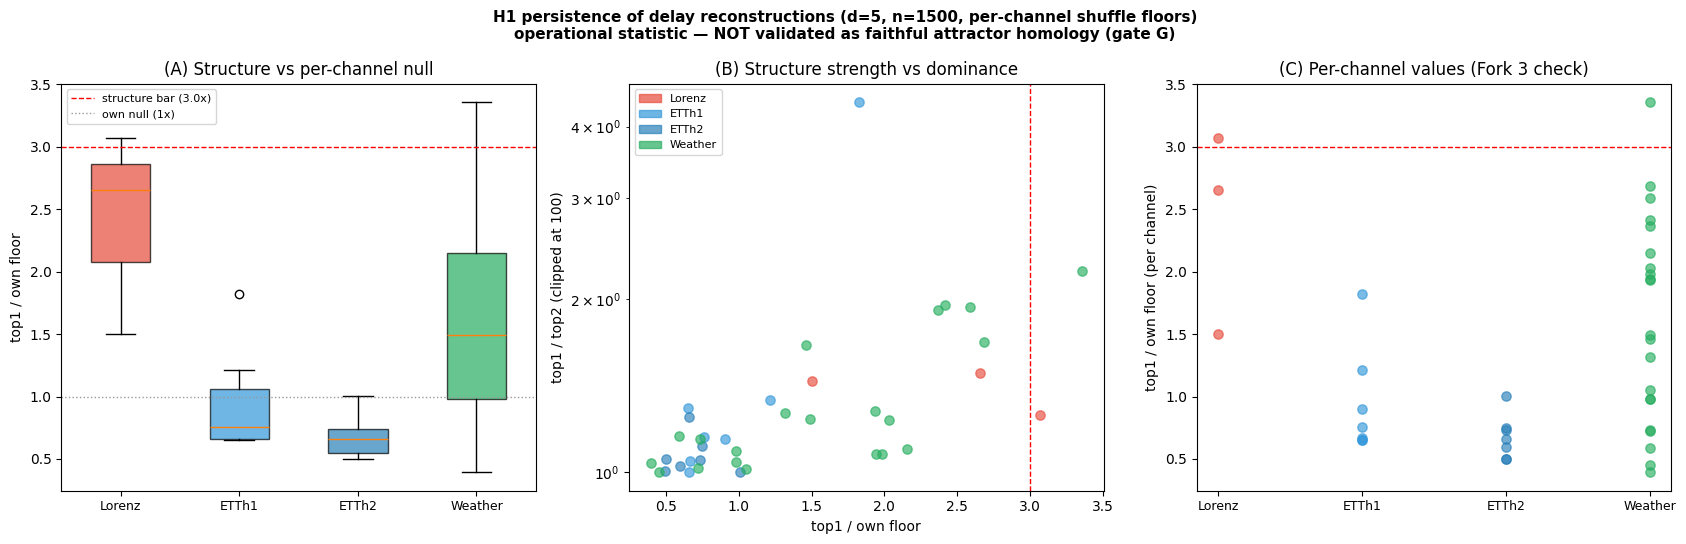

Saved tda_real_results_v2.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = {'Lorenz': '#e74c3c', 'ETTh1': '#3498db', 'ETTh2': '#2980b9', 'Weather': '#27ae60'}
order = ['Lorenz', 'ETTh1', 'ETTh2', 'Weather']

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
fig.suptitle('H1 persistence of delay reconstructions (d=5, n=1500, per-channel shuffle floors)\n'
             'operational statistic — NOT validated as faithful attractor homology (gate G)',
             fontsize=11, fontweight='bold')

ax = axes[0]
box = [df_ch[df_ch.dataset == d].top1_over_floor.values for d in order]
bp = ax.boxplot(box, patch_artist=True, widths=0.5)
for patch, dname in zip(bp['boxes'], order):
    patch.set_facecolor(colors[dname]); patch.set_alpha(0.7)
ax.axhline(STRUCT_BAR, color='r', ls='--', lw=1, label=f'structure bar ({STRUCT_BAR}x)')
ax.axhline(1.0, color='0.6', ls=':', lw=1, label='own null (1x)')
ax.set_xticks(range(1, 5)); ax.set_xticklabels(order, fontsize=9)
ax.set_ylabel('top1 / own floor'); ax.legend(fontsize=8)
ax.set_title('(A) Structure vs per-channel null')

ax = axes[1]
for dname in order:
    s = df_ch[df_ch.dataset == dname]
    ax.scatter(s.top1_over_floor, s.top1_over_top2.clip(upper=100),
               color=colors[dname], alpha=0.65, s=45)
ax.axvline(STRUCT_BAR, color='r', ls='--', lw=1)
ax.set_xlabel('top1 / own floor'); ax.set_ylabel('top1 / top2 (clipped at 100)')
ax.set_yscale('log')
handles = [mpatches.Patch(color=colors[d], label=d, alpha=0.7) for d in order]
ax.legend(handles=handles, fontsize=8)
ax.set_title('(B) Structure strength vs dominance')

ax = axes[2]
for j, dname in enumerate(order):
    s = df_ch[df_ch.dataset == dname].sort_values('top1_over_floor', ascending=False)
    ax.scatter([j + 1] * len(s), s.top1_over_floor, color=colors[dname], alpha=0.65, s=45)
ax.axhline(STRUCT_BAR, color='r', ls='--', lw=1)
ax.set_xticks(range(1, 5)); ax.set_xticklabels(order, fontsize=9)
ax.set_ylabel('top1 / own floor (per channel)')
ax.set_title('(C) Per-channel values (Fork 3 check)')

plt.tight_layout()
plt.savefig('tda_real_results_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tda_real_results_v2.png")

## Interpretation — apply the PRE-REGISTERED forks from the header

1. Read frac_structured and the boxplot: FORK 1 (Weather structured,
   ETTh not), FORK 2 (no separation), or FORK 3 (Weather internally split)?
2. Lorenz reference check: x,y channels should clear the bar and z should
   be weak (folded z-reconstruction) — if not, flag before interpreting
   anything else; this is the in-run replication of gate C.
3. Confound checklist before any conclusion: dominant-period-to-sampling
   ratio per channel (tau near MAX_TAU suggests under-resolved slow
   cycles), sensor quantisation (step-like channels), non-stationarity
   within the 3000-sample window.
4. Whatever the fork: the result is CORRELATIONAL. The causal test is
   synthetic interpolation (construct signals sweeping this statistic at
   matched difficulty), which is only worth designing under Fork 1 or 3.